# EE 344 — Assignment 5: Power-System Fault Classification with Deep Neural Networks

In this assignment, you will predict **power-system fault conditions** from 6 input measurements using **PyTorch**.
There are many ways to implement DNNs for prediction tasks; here you will implement and compare **three** common setups.

**Dataset**: `classData.csv`

**Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`  
**Outputs**: 4-bit label `[G, C, B, A]`

Dataset (Kaggle): https://www.kaggle.com/datasets/esathyaprakash/electrical-fault-detection-and-classification

**Note:** Do **NOT** download the dataset from Kaggle. Use the dataset file provided on Canvas with this assignment.

Your tasks:
1. **Part 1** — Regression-style DNN to predict 4 outputs (then round to bits).
2. **Part 2** — Multi-label DNN to predict 4 bits (sigmoid / BCE-style loss).
3. **Part 3** — Multi-class DNN to predict no fault and 5 fault types (softmax / cross-entropy).
4. **Part 4** — Brief discussion: which approach is best and why.
5. **Part 5** — Open-ended: build a **binary** classifier (Fault vs No Fault) using the best approach.


## Setup
Run the next cell to import libraries and define helper functions.

In [47]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def plot_cm(cm, title, labels):
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha='right')
    plt.yticks(ticks, labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def bit_reports(Y_true_bits, Y_pred_bits, split_name='Test', bit_names=('G','C','B','A')):
    """Multi-label report + per-bit 2x2 confusion matrices."""
    print(f"\n=== Bit-level Report | {split_name} ===")
    print(classification_report(Y_true_bits, Y_pred_bits, target_names=list(bit_names), digits=4))
    for j, lab in enumerate(bit_names):
        cm = confusion_matrix(Y_true_bits[:, j], Y_pred_bits[:, j], labels=[0, 1])
        print(f"\nBit {lab} | {split_name} CM (rows=true 0/1, cols=pred 0/1):\n{cm}")


Device: cpu


## Dataset

The file `classData.csv` contains a dataset for classifying fault conditions.

- **Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`
- **Outputs**: `[G, C, B, A]`

Examples:
- `[0 0 0 0]` — No Fault
- `[1 0 0 1]` — LG fault (Phase A to ground)
- `[0 0 1 1]` — LL fault (Phase A to Phase B)
- `[1 0 1 1]` — LLG fault (Phases A,B to ground)
- `[0 1 1 1]` — LLL fault (all three phases)
- `[1 1 1 1]` — LLLG fault (three phases + ground)


In [48]:
# ----------------------------
# Load data + create targets
# ----------------------------
CSV_PATH = 'classData.csv'
df = pd.read_csv(CSV_PATH)

label_cols = ['G','C','B','A']
feature_cols = ['Ia','Ib','Ic','Va','Vb','Vc']

missing = [c for c in (label_cols + feature_cols) if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Found: {list(df.columns)}")

X = df[feature_cols].astype(np.float32).values            # (N,6)
Y_bits = df[label_cols].astype(int).values                # (N,4)

FAULT_NAMES = ['No Fault','LG','LL','LLG','LLL','LLLG']

def bits_to_fault_type_idx(bits_gcba):
    G, C, B, A = map(int, bits_gcba)
    n_phase = C + B + A
    if G == 0 and n_phase == 0: return 0
    if G == 1 and n_phase == 1: return 1
    if G == 0 and n_phase == 2: return 2
    if G == 1 and n_phase == 2: return 3
    if G == 0 and n_phase == 3: return 4
    if G == 1 and n_phase == 3: return 5
    raise ValueError(f"Unexpected pattern [G,C,B,A]={bits_gcba}")

y_fault = np.array([bits_to_fault_type_idx(row) for row in Y_bits], dtype=int)
print('Fault counts:', dict(zip(FAULT_NAMES, np.bincount(y_fault, minlength=len(FAULT_NAMES)))))

# One shared split (recommended for fair comparison across Parts 1–3)
X_train, X_test, Y_train, Y_test, y_fault_train, y_fault_test = train_test_split(
    X, Y_bits, y_fault, test_size=0.30, random_state=RANDOM_STATE, stratify=y_fault
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])


Fault counts: {'No Fault': np.int64(2365), 'LG': np.int64(1129), 'LL': np.int64(1004), 'LLG': np.int64(1134), 'LLL': np.int64(1096), 'LLLG': np.int64(1133)}
Train size: 5502 | Test size: 2359


## Part 1 — DNN Model 1 (Regression-style 4-output model)

You will build a DNN that outputs **4 real-valued numbers** and train it with **MSE**.
During evaluation, you will **round** predictions to the nearest integer, clamp to `{0,1}`, and then compare against the true 4-bit label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 (linear)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**


In [49]:
# ----------------------------
# Part 1: Robust scaling (fit on train only)
# ----------------------------
scaler_1 = RobustScaler()
X_train_s1 = scaler_1.fit_transform(X_train).astype(np.float32)
X_test_s1  = scaler_1.transform(X_test).astype(np.float32)

# Torch datasets
Xtr = torch.from_numpy(X_train_s1)
Xte = torch.from_numpy(X_test_s1)
Ytr = torch.from_numpy(Y_train.astype(np.float32))
Yte = torch.from_numpy(Y_test.astype(np.float32))

BATCH_SIZE = 256
train_loader_1 = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)

# Hyperparameters
INPUT_DIM = 6
H1 = 16
H2 = 8
OUT_DIM = 4
DROPOUT_P = 0.25
L2_WEIGHT_DECAY = 1e-4
LR = 1e-3
EPOCHS = 1000


In [50]:
## [ TODO 1 ]
# Define the DNN for Part 1 using PyTorch.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: linear (no activation)
# - Use BatchNorm and Dropout in hidden layers
#
# Write your model class below.

class DNN_Reg4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        # TODO: define layers (Linear, BatchNorm1d, Dropout, etc.)
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(p_drop),

            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(p_drop),

            nn.Linear(h2, out_dim)
       )

    def forward(self, x):
        # TODO: implement forward pass
        return self.net(x)



In [51]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: MSE
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

# model = DNN_Reg4(...).to(device)
# loss_fn = ...
# optimizer = ...
model = DNN_Reg4().to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=L2_WEIGHT_DECAY)


In [52]:
# ----------------------------
# Training loop (you fill the key missing pieces)
# ----------------------------
## [ TODO 3 ]
def train_part1(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)


            optimizer.zero_grad()
            preds = model(xb)
            loss = loss_fn(preds, yb)
            loss.backward()
            optimizer.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs//2, epochs]:
              avg_loss = total / len(loader.dataset)
              print(f"Epoch {ep:4d} | MSE Loss: {avg_loss:.6f}")

@torch.no_grad()
def predict_part1(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    out = model(X_t).cpu().numpy()  # (N,4) real-valued
    return out

# TODO: Train the model
train_part1(model, train_loader_1, epochs=EPOCHS)

Epoch    1 | MSE Loss: 0.766126
Epoch  500 | MSE Loss: 0.102731
Epoch 1000 | MSE Loss: 0.102912


In [53]:
# ----------------------------
# Evaluation (round -> clamp to {0,1} -> report)
# ----------------------------
yhat_train = predict_part1(model, X_train_s1)
yhat_test  = predict_part1(model, X_test_s1)
# After you obtain yhat_* (shape N x 4):
pred_bits_train = np.clip(np.rint(yhat_train).astype(int), 0, 1)
pred_bits_test  = np.clip(np.rint(yhat_test ).astype(int), 0, 1)
bit_reports(Y_train, pred_bits_train, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.8992    0.7690    0.8290      2377
           C     0.9924    0.9174    0.9534      2263
           B     0.9452    0.9653    0.9552      3057
           A     0.9781    0.9793    0.9787      3144

   micro avg     0.9557    0.9163    0.9356     10841
   macro avg     0.9537    0.9078    0.9291     10841
weighted avg     0.9545    0.9163    0.9340     10841
 samples avg     0.6610    0.6477    0.6486     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2920  205]
 [ 549 1828]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3223   16]
 [ 187 2076]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2274  171]
 [ 106 2951]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2289   69]
 [  65 3079]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.8995    0.7556    0.8213      1019
           C     0.9845    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

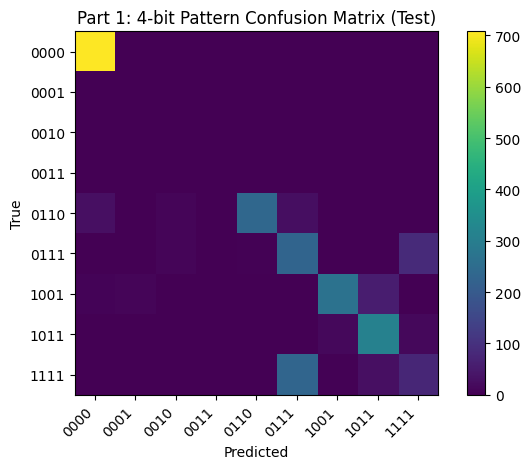

[[708   1   0   0   0   0   1   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [ 28   0  11   0 237  25   0   0   0]
 [  0   0  11   0   4 229   0   0  85]
 [  7   9   0   0   0   0 266  57   0]
 [  0   0   0   1   0   0  14 311  14]
 [  0   0   0   0   0 232   4  29  75]]


In [34]:
# One confusion matrix over full 4-bit patterns (for TEST set)
true_str = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str = [''.join(map(str, r.tolist())) for r in pred_bits_test]
labels = sorted(list(set(true_str) | set(pred_str)))
cm = confusion_matrix(true_str, pred_str, labels=labels)
plot_cm(cm, 'Part 1: 4-bit Pattern Confusion Matrix (Test)', labels)
print(cm)

## Part 2 — DNN Model 2 (Multi-label 4-bit classification)

You will build a DNN that predicts the 4 bits `[G, C, B, A]` as a **multi-label** output.
Each output dimension is an independent binary label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 logits (apply sigmoid only for evaluation)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use a **binary cross-entropy style loss on logits** (do not apply sigmoid inside the model).


In [13]:
# ----------------------------
# Part 2: Robust scaling (fit on train only)
# ----------------------------
scaler_2 = RobustScaler()
X_train_s2 = scaler_2.fit_transform(X_train).astype(np.float32)
X_test_s2  = scaler_2.transform(X_test).astype(np.float32)

Xtr2 = torch.from_numpy(X_train_s2)
Xte2 = torch.from_numpy(X_test_s2)
Ytr2 = torch.from_numpy(Y_train.astype(np.float32))
Yte2 = torch.from_numpy(Y_test.astype(np.float32))

train_loader_2 = DataLoader(TensorDataset(Xtr2, Ytr2), batch_size=BATCH_SIZE, shuffle=True)


In [15]:
## [ TODO 1 ]
# Define the DNN for Part 2.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: 4 logits (no sigmoid inside the model)
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiLabel4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()

        # Layer 1
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)

        # Layer 2
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)

        # Output layer (4 logits)
        self.out = nn.Linear(h2, out_dim)

    def forward(self, x):
        # TODO: forward pass returning logits (N,4)
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.drop2(x)

        logits = self.out(x)   # NO sigmoid here
        return logits


In [18]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: binary cross-entropy style loss on logits -- BCEWithLogitsLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

# TODO: model = ...
# TODO: loss_fn = ...
# TODO: optimizer = ...
model = DNN_MultiLabel4().to(device)

loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [22]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3]
def train_part2(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # TODO: zero gradients
            optimizer.zero_grad()

            # TODO: logits = model(xb)
            logits = model(xb)

            # TODO: loss = loss_fn(logits, yb)
            loss = loss_fn(logits, yb)

            # TODO: backward + step
            loss.backward()

            # total += loss.item() * xb.size(0)
            total += loss.item() * xb.size(0)

        avg_loss = total / len(loader.dataset)


        if ep in [1, epochs//2, epochs]:
            print(f"Epoch {ep:3d}/{epochs} | Loss: {avg_loss:.4f}")

@torch.no_grad()
def predict_bits_part2(model, X_np, threshold=0.5):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    probs = torch.sigmoid(logits).cpu().numpy()
    pred_bits = (probs >= threshold).astype(int)
    return pred_bits

# TODO: Train the model
train_part2(model, train_loader_2)


Epoch   1/1000 | Loss: 0.7203
Epoch 500/1000 | Loss: 0.7196
Epoch 1000/1000 | Loss: 0.7209


In [20]:
# ----------------------------
# Evaluation
# ----------------------------
pred_bits_train_ = predict_bits_part2(model, X_train_s2)
pred_bits_test_  = predict_bits_part2(model, X_test_s2)

bit_reports(Y_train, pred_bits_train_, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test_,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.0000    0.0000    0.0000      2377
           C     0.4113    1.0000    0.5829      2263
           B     0.4880    0.7190    0.5814      3057
           A     0.4726    0.3349    0.3920      3144

   micro avg     0.4507    0.5086    0.4779     10841
   macro avg     0.3430    0.5135    0.3891     10841
weighted avg     0.3605    0.5086    0.3993     10841
 samples avg     0.4602    0.3488    0.3804     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[3125    0]
 [2377    0]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[   0 3239]
 [   0 2263]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[ 139 2306]
 [ 859 2198]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[1183 1175]
 [2091 1053]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.0000    0.0000    0.0000      1019
           C     0.4112    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

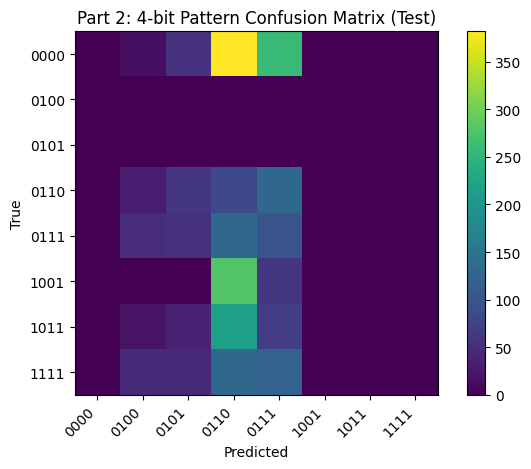

[[  0  16  55 382 257   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0]
 [  0  29  60  85 127   0   0   0]
 [  0  49  54 126 100   0   0   0]
 [  0   0   0 278  61   0   0   0]
 [  0  20  35 216  69   0   0   0]
 [  0  45  46 129 120   0   0   0]]


In [21]:
# One confusion matrix over full 4-bit patterns (For TEST set)
true_str_ = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str_ = [''.join(map(str, r.tolist())) for r in pred_bits_test_]
labels_ = sorted(list(set(true_str_) | set(pred_str_)))
cm_ = confusion_matrix(true_str_, pred_str_, labels=labels_)
plot_cm(cm_, 'Part 2: 4-bit Pattern Confusion Matrix (Test)', labels_)
print(cm_)

## Part 3 — DNN Model 3 (Multi-class fault type classification)

In this part, you will predict one of **6 fault types**.
The 4-bit label is converted to a single class in `{0,1,2,3,4,5}` using the provided mapping.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 6 logits
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use **cross-entropy loss** for multi-class classification.


In [23]:
# ----------------------------
# Part 3: Robust scaling (fit on train only)
# ----------------------------
scaler_3 = RobustScaler()
X_train_s3 = scaler_3.fit_transform(X_train).astype(np.float32)
X_test_s3  = scaler_3.transform(X_test).astype(np.float32)

ytr3 = torch.from_numpy(y_fault_train.astype(np.int64))
yte3 = torch.from_numpy(y_fault_test.astype(np.int64))
Xtr3 = torch.from_numpy(X_train_s3)
Xte3 = torch.from_numpy(X_test_s3)

train_loader_3 = DataLoader(TensorDataset(Xtr3, ytr3), batch_size=BATCH_SIZE, shuffle=True)


In [24]:
## [ TODO 1 ]
# Define the DNN for Part 3.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 6
# - Hidden activations: ReLU
# - Output: 6 logits
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiClass6(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, num_classes=6, p_drop=DROPOUT_P):
        super().__init__()

        # Layer 1
        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)

        # Layer 2
        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)

        # Output layer (6 logits)
        self.out = nn.Linear(h2, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.drop1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.drop2(x)

        logits = self.out(x)
        return logits


In [25]:
## [ TODO 2 ]
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: CrossEntropyLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

# TODO: model = ...
# TODO: loss_fn = ...
# TODO: optimizer = ...
model = DNN_MultiClass6().to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)


In [32]:
# ----------------------------
# Training loop scaffold
# ----------------------------
## [ TODO 3 ]
def train_part3(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            # TODO: zero gradients
            optimizer.zero_grad()

            # TODO: logits = model(xb)
            logits = model(xb)

            # TODO: loss = loss_fn(logits, yb)
            loss = loss_fn(logits, yb)

            # TODO: backward + step
            loss.backward()
            optimizer.step()

            # total += loss.item() * xb.size(0)
            total += loss.item() * xb.size(0)

            avg_loss = total / len(loader.dataset)

            if ep in [1, epochs//2, epochs]:
                print(f"Epoch {ep:3d}/{epochs} | Loss: {avg_loss:.4f}")

train_part3(model, train_loader_3)

@torch.no_grad()
def predict_part3(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    return torch.argmax(logits, dim=1).cpu().numpy()


Epoch   1/1000 | Loss: 0.0324
Epoch   1/1000 | Loss: 0.0589
Epoch   1/1000 | Loss: 0.0850
Epoch   1/1000 | Loss: 0.1169
Epoch   1/1000 | Loss: 0.1471
Epoch   1/1000 | Loss: 0.1772
Epoch   1/1000 | Loss: 0.2065
Epoch   1/1000 | Loss: 0.2347
Epoch   1/1000 | Loss: 0.2662
Epoch   1/1000 | Loss: 0.2938
Epoch   1/1000 | Loss: 0.3242
Epoch   1/1000 | Loss: 0.3474
Epoch   1/1000 | Loss: 0.3730
Epoch   1/1000 | Loss: 0.4064
Epoch   1/1000 | Loss: 0.4332
Epoch   1/1000 | Loss: 0.4581
Epoch   1/1000 | Loss: 0.4876
Epoch   1/1000 | Loss: 0.5133
Epoch   1/1000 | Loss: 0.5411
Epoch   1/1000 | Loss: 0.5675
Epoch   1/1000 | Loss: 0.5978
Epoch   1/1000 | Loss: 0.6143
Epoch 500/1000 | Loss: 0.0247
Epoch 500/1000 | Loss: 0.0534
Epoch 500/1000 | Loss: 0.0829
Epoch 500/1000 | Loss: 0.1172
Epoch 500/1000 | Loss: 0.1463
Epoch 500/1000 | Loss: 0.1731
Epoch 500/1000 | Loss: 0.2016
Epoch 500/1000 | Loss: 0.2295
Epoch 500/1000 | Loss: 0.2565
Epoch 500/1000 | Loss: 0.2840
Epoch 500/1000 | Loss: 0.3145
Epoch 500/


=== Part 3 | Train ===
              precision    recall  f1-score   support

    No Fault     0.9506    1.0000    0.9747      1655
          LG     0.8401    0.9443    0.8892       790
          LL     0.9178    0.9374    0.9275       703
         LLG     0.8571    0.8766    0.8667       794
         LLL     0.6382    0.2438    0.3528       767
        LLLG     0.5124    0.6784    0.5838       793

    accuracy                         0.8144      5502
   macro avg     0.7860    0.7801    0.7658      5502
weighted avg     0.8104    0.8144    0.7978      5502



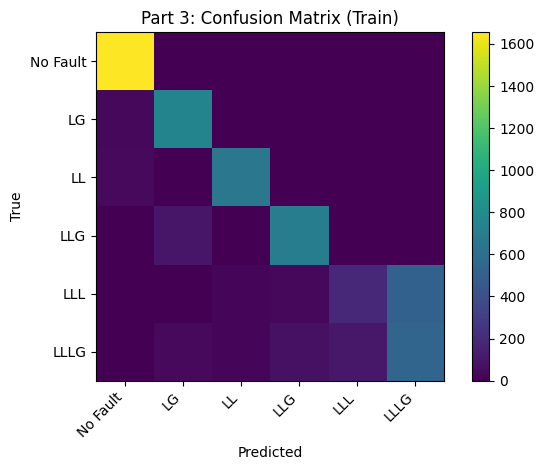


=== Part 3 | Test ===
              precision    recall  f1-score   support

    No Fault     0.9454    1.0000    0.9719       710
          LG     0.8417    0.9410    0.8886       339
          LL     0.9243    0.9336    0.9289       301
         LLG     0.8853    0.8853    0.8853       340
         LLL     0.4632    0.1915    0.2710       329
        LLLG     0.4766    0.6294    0.5425       340

    accuracy                         0.8003      2359
   macro avg     0.7561    0.7635    0.7480      2359
weighted avg     0.7843    0.8003    0.7823      2359



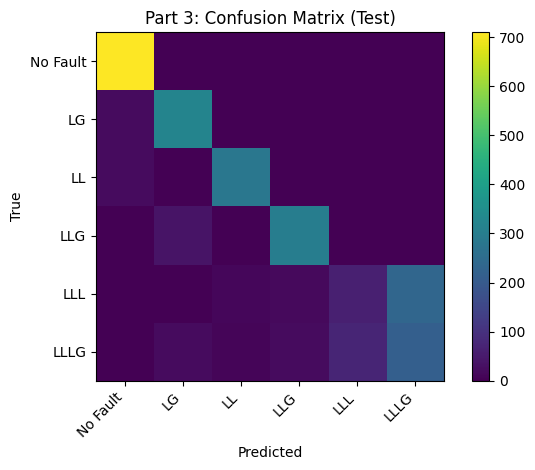

In [33]:
# ----------------------------
# Evaluation
# ----------------------------
pred_train = predict_part3(model, X_train_s3)
pred_test  = predict_part3(model, X_test_s3)

print('\n=== Part 3 | Train ===')
print(classification_report(y_fault_train, pred_train, target_names=FAULT_NAMES, digits=4))
cm_tr = confusion_matrix(y_fault_train, pred_train, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_tr, 'Part 3: Confusion Matrix (Train)', FAULT_NAMES)

print('\n=== Part 3 | Test ===')
print(classification_report(y_fault_test, pred_test, target_names=FAULT_NAMES, digits=4))
cm_te = confusion_matrix(y_fault_test, pred_test, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_te, 'Part 3: Confusion Matrix (Test)', FAULT_NAMES)


## Part 4 — Discussion

Answer **2–5 sentences** for each prompt.

1. Compare Parts 1–3. Which formulation fits this dataset best (regression-style, multi-label, or multi-class), and why?
2. When you used the bit-based approaches (Part 1 and Part 2), did you observe any **inconsistent 4-bit outputs** (invalid fault patterns)? What does that suggest?
3. Looking at confusion matrices, which fault types (or bit positions) were the hardest to predict? Give one plausible reason.

### Your answers
- Q1: The multi-class model in Part 3 fits this dataset the best. In this problem, each example really belongs to just one fault type, so treating it as a 6-class classification task makes the most sense. The multi-label model didn’t work well and basically failed on some of the bits, and while the regression-style model did pretty well on individual bits, it doesn’t actually force the prediction to be just one fault type. Because of that, the multi-class setup matches the structure of the data better and gives more reliable results overall.

- Q2: Yes, with the bit-based approaches (Parts 1 and 2), I can definitely get 4-bit combinations that don’t actually match any real fault type in the dataset. Since each bit is predicted separately, the model isn’t forced to pick one of the valid fault patterns it just predicts each bit on its own. This especially shows up in the multi-label setup, where the bits are treated as completely independent. That suggests the bits aren’t really independent labels, but part of one structured output that represents a single fault type. So it makes more sense to model it as one multi-class problem instead of separate bits.

- Q3: Looking at the confusion matrices, LLL and LLLG were definitely the hardest ones. The model kept mixing them up, especially LLL. I’m guessing that’s because those two faults are pretty similar since they both involve three phases, so the voltage and current values probably look almost the same to the model. For the bit models, Bit G was kind of a mess in Part 2. It basically didn’t learn it at all. That probably means that bit was harder to separate or maybe the data for it wasn’t as balanced as the others.


## Part 5 — Open-ended extension: Binary classification (Fault vs No Fault)

In this part, you will create a **binary** classification problem:

- Class 0: **No Fault** (`[0,0,0,0]`)
- Class 1: **Fault** (any other pattern)

**Your task**: Using the best formulation you identified in Part 4, build a DNN to classify **Fault vs No Fault**.

Requirements:
- Use a **70% / 30%** train/test split (stratified)
- Use **RobustScaler** (fit on train only)
- Report **classification report** and **confusion matrix** on **train and test**

Implementation notes:
- First create a dataset with two classes by compressing all fault types into a single “Fault” class (and keeping “No Fault” as the other class).
- Keep your solution clean and focused: data, model, training, evaluation.


In [35]:
# Create Binary Labels
y_binary = (y_fault != 0).astype(int)

# Stratified Split (70/30)
from sklearn.model_selection import train_test_split

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X,
    y_binary,
    test_size=0.30,
    stratify=y_binary,
    random_state=42
)


In [36]:
from sklearn.preprocessing import RobustScaler

scaler_bin = RobustScaler()
X_train_b_s = scaler_bin.fit_transform(X_train_b).astype(np.float32)
X_test_b_s  = scaler_bin.transform(X_test_b).astype(np.float32)

# Convert to Torch
import torch
from torch.utils.data import DataLoader, TensorDataset

Xtr_b = torch.from_numpy(X_train_b_s)
Xte_b = torch.from_numpy(X_test_b_s)

ytr_b = torch.from_numpy(y_train_b.astype(np.int64))
yte_b = torch.from_numpy(y_test_b.astype(np.int64))

train_loader_b = DataLoader(
    TensorDataset(Xtr_b, ytr_b),
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [37]:
class DNN_Binary(nn.Module):
    def __init__(self, input_dim=6, h1=16, h2=8, num_classes=2, p_drop=0.3):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, h1)
        self.bn1 = nn.BatchNorm1d(h1)
        self.drop1 = nn.Dropout(p_drop)

        self.fc2 = nn.Linear(h1, h2)
        self.bn2 = nn.BatchNorm1d(h2)
        self.drop2 = nn.Dropout(p_drop)

        self.out = nn.Linear(h2, num_classes)

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.drop1(x)

        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.drop2(x)

        return self.out(x)

In [40]:
# Loss + Optimizer
model_b = DNN_Binary().to(device)

loss_fn_b = nn.CrossEntropyLoss()

optimizer_b = torch.optim.Adam(
    model_b.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [41]:
# Training Function
def train_binary(model, loader, epochs=EPOCHS):
    model.train()

    for ep in range(1, epochs + 1):
        total = 0.0

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer_b.zero_grad()
            logits = model(xb)
            loss = loss_fn_b(logits, yb)

            loss.backward()
            optimizer_b.step()

            total += loss.item() * xb.size(0)

        avg_loss = total / len(loader.dataset)

        if ep in [1, epochs//2, epochs]:
            print(f"Epoch {ep}/{epochs} | Loss: {avg_loss:.4f}")

train_binary(model_b, train_loader_b)

Epoch 1/1000 | Loss: 0.9532
Epoch 500/1000 | Loss: 0.0919
Epoch 1000/1000 | Loss: 0.0806


In [42]:
@torch.no_grad()
def predict_binary(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    return torch.argmax(logits, dim=1).cpu().numpy()

pred_train_b = predict_binary(model_b, X_train_b_s)
pred_test_b  = predict_binary(model_b, X_test_b_s)

print("\n=== Binary | Train ===")
print(classification_report(y_train_b, pred_train_b, digits=4))
print(confusion_matrix(y_train_b, pred_train_b))

print("\n=== Binary | Test ===")
print(classification_report(y_test_b, pred_test_b, digits=4))
print(confusion_matrix(y_test_b, pred_test_b))


=== Binary | Train ===
              precision    recall  f1-score   support

           0     0.9555    0.9994    0.9770      1655
           1     0.9997    0.9800    0.9898      3847

    accuracy                         0.9858      5502
   macro avg     0.9776    0.9897    0.9834      5502
weighted avg     0.9864    0.9858    0.9859      5502

[[1654    1]
 [  77 3770]]

=== Binary | Test ===
              precision    recall  f1-score   support

           0     0.9660    1.0000    0.9827       710
           1     1.0000    0.9848    0.9924      1649

    accuracy                         0.9894      2359
   macro avg     0.9830    0.9924    0.9875      2359
weighted avg     0.9898    0.9894    0.9895      2359

[[ 710    0]
 [  25 1624]]
